# Étapes 4 & 5 — Entraînement des modèles et métriques

Ce notebook déroule ce que fait `train.py`, en observant chaque niveau :

1. Chargement du dataset nettoyé
2. **Niveau 1** — statistiques IQR par opérateur (repli robuste)
3. **Niveau 2** — Isolation Forest (anomalies multivariées)
4. **Niveau 3** — régression Gradient Boosting (prédiction du débit)
5. **Étape 5** — évaluation honnête (split temporel, MAE vs référence naïve)
6. Détection d'anomalies sur les mesures récentes
7. Prévision 48 h et sauvegarde du modèle (`yele_ai.joblib`)

> Prérequis : avoir exécuté `01_nettoyage.ipynb` (ou `python prepare_data.py`).

## 1. Charger le dataset nettoyé

In [1]:
import pandas as pd
from model import YeleAI, MIN_SAMPLES_ML, KPI, FEATURES

df = pd.read_csv('dataset_clean.csv', parse_dates=['timestamp'])
print(f'{len(df)} mesures — seuil ML : {MIN_SAMPLES_ML}')
print(f'Variables des modèles : KPI={KPI}, contexte={FEATURES}')

c:\Users\djmlgck\Desktop\ISGE\Stage\CITADEL\ai\.venv\Lib\site-packages\torch\cuda\__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


137 mesures — seuil ML : 50
Variables des modèles : KPI=['dl', 'ul', 'ping', 'jitter'], contexte=['hour', 'dayofweek', 'is_weekend', 'op_code', 'net_code']


## 2. Entraînement complet
`ai.train(df)` fabrique les trois niveaux d'un coup. Avant cet appel, l'objet est vide ;
après, il contient tout le « savoir » extrait de tes mesures.

In [2]:
ai = YeleAI()
ai.train(df)
print('Mesures apprises :', ai.n_samples)
print('ML actif :', ai.ml_ready, '(False = stats IQR seulement, car < 50 mesures)')

Mesures apprises : 137
ML actif : True (False = stats IQR seulement, car < 50 mesures)


### Niveau 1 — ce que le modèle a mémorisé par opérateur
La « normale » de chaque opérateur : médiane et quartiles du débit.
C'est ce qui permet de dire *« 5 Mb/s est anormal pour Orange (médiane 25) mais normal pour X »*.

In [3]:
pd.DataFrame(ai.group_stats).T.round(1).sort_values('count', ascending=False)

,count,dl_median,dl_q1,dl_q3,dl_q05,ping_median
Orange Burkina Faso,47.0,26.5,19.0,50.8,7.3,324.9
ANPTIC,42.0,17.4,3.1,41.0,1.1,485.7
Inconnu,20.0,48.4,1.1,72.6,0.7,267.9
ONATEL / Telmob,17.0,8.4,6.0,24.3,2.6,395.6
ARCEP Burkina,8.0,18.4,12.6,38.0,12.2,317.9
GVA Cote d'Ivoire SAS,2.0,12.6,12.1,13.0,11.8,376.0
Green Mini host BV,1.0,19.4,19.4,19.4,19.4,177.4


## 3. Étape 5 — Évaluation honnête de la prédiction
**Règle d'or** : on évalue sur des données que le modèle n'a **jamais vues**, et pour une
série temporelle on coupe **chronologiquement** (apprendre sur le passé, prédire le « futur »).

- **MAE** (Mean Absolute Error) : erreur moyenne en Mb/s — plus c'est bas, mieux c'est.
- **Référence naïve** : prédire toujours la médiane. Si le modèle ne bat pas ça, il n'apporte rien.

In [4]:
import numpy as np

df_sorted = df.sort_values('timestamp')
cut = int(len(df_sorted) * 0.8)
train_df, test_df = df_sorted.iloc[:cut], df_sorted.iloc[cut:]
print(f'Apprentissage : {len(train_df)} mesures (les plus anciennes)')
print(f'Test          : {len(test_df)} mesures (les plus récentes, jamais vues)')

eval_ai = YeleAI()
eval_ai.train(train_df)
if eval_ai.ml_ready:
    pred = eval_ai.reg.predict(eval_ai._features(test_df))
    mae = np.mean(np.abs(test_df['dl'].to_numpy() - pred))
    baseline = np.mean(np.abs(test_df['dl'].to_numpy() - train_df['dl'].median()))
    print(f'\nMAE du modèle      : {mae:.1f} Mb/s')
    print(f'Référence naïve    : {baseline:.1f} Mb/s (prédire toujours la médiane)')
    print('=> le modèle', 'BAT la référence ✓' if mae < baseline else 'ne bat PAS encore la référence — plus de données nécessaires')
else:
    print('Pas assez de mesures dans la partie apprentissage pour le ML.')

Apprentissage : 109 mesures (les plus anciennes)
Test          : 28 mesures (les plus récentes, jamais vues)

MAE du modèle      : 21.6 Mb/s
Référence naïve    : 17.5 Mb/s (prédire toujours la médiane)
=> le modèle ne bat PAS encore la référence — plus de données nécessaires


### Visualiser prédit vs mesuré (sur le jeu de test)

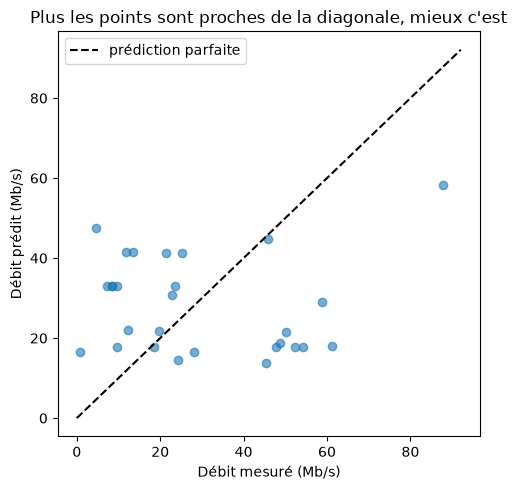

In [5]:
import matplotlib.pyplot as plt
if eval_ai.ml_ready:
    plt.figure(figsize=(5, 5))
    plt.scatter(test_df['dl'], pred, alpha=0.6)
    lim = max(test_df['dl'].max(), pred.max()) * 1.05
    plt.plot([0, lim], [0, lim], 'k--', label='prédiction parfaite')
    plt.xlabel('Débit mesuré (Mb/s)'); plt.ylabel('Débit prédit (Mb/s)')
    plt.title('Plus les points sont proches de la diagonale, mieux c\'est')
    plt.legend(); plt.tight_layout(); plt.show()

## 4. Détection d'anomalies
On score les mesures des 30 derniers jours. Chaque anomalie a une **sévérité** (0-100)
et des **raisons lisibles** — indispensables pour qu'un humain puisse vérifier.

In [6]:
recent = df[df['timestamp'] >= df['timestamp'].max() - pd.Timedelta(days=30)]
anomalies = ai.detect(recent, limit=10)
print(f'{len(anomalies)} anomalies sur {len(recent)} mesures récentes\n')
for a in anomalies:
    print(f"[{a['severity']:>3}/100] {a['timestamp'][:16]} {a['operator']} — {a['download']} Mb/s")
    for r in a['reasons']:
        print(f'         · {r}')

3 anomalies sur 17 mesures récentes

[ 94/100] 2026-07-28T20:31 ONATEL / Telmob — 0.79 Mb/s
         · Débit 0.8 Mb/s très en dessous de la normale de ONATEL / Telmob (médiane 8.4 Mb/s)
         · Latence 2677 ms ≈ 7× la médiane de ONATEL / Telmob
         · Combinaison de mesures atypique (Isolation Forest)
[ 40/100] 2026-07-14T19:48 Orange Burkina Faso — 7.23 Mb/s
         · Débit 7.2 Mb/s très en dessous de la normale de Orange Burkina Faso (médiane 26.5 Mb/s)
[ 30/100] 2026-07-29T10:55 ANPTIC — 50.28 Mb/s
         · Combinaison de mesures atypique (Isolation Forest)


## 5. Prévision 48 h (si le ML est actif)

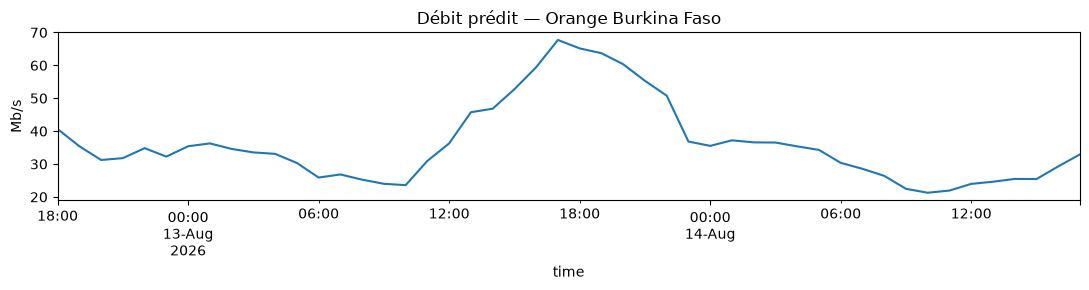

In [7]:
if ai.ml_ready and ai.operators:
    op = df['operator'].value_counts().index[0]
    fc = ai.forecast(op, hours=48)
    fdf = pd.DataFrame(fc)
    fdf['time'] = pd.to_datetime(fdf['time'])
    fdf.set_index('time')['predictedDownload'].plot(figsize=(11, 3), title=f'Débit prédit — {op}')
    plt.ylabel('Mb/s'); plt.tight_layout(); plt.show()
else:
    print('Prévision indisponible : ML inactif (moins de 50 mesures).')

## 6. Sauvegarde : le modèle devient un fichier
La **sérialisation** écrit l'objet entraîné sur disque. Le service web (`service.py`)
le rechargera sans devoir ré-apprendre.

In [8]:
import joblib, os
joblib.dump(ai, 'yele_ai.joblib')
print(f"yele_ai.joblib créé ({os.path.getsize('yele_ai.joblib') / 1024:.0f} Ko)")

yele_ai.joblib créé (45105 Ko)
